# A007 temperature logger Loch Etive 2026-06-01

## Step 1: Import packages for use in Python code and define some functions to use

In [1]:
#Programes and functions
import pandas as pd
import numpy as np
import contextily as ctx
import geopandas as gpd
import datetime
import matplotlib as mpl
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import matplotlib.ticker as mticker
import cmocean
from datetime import datetime
from matplotlib import pyplot as plt 
from geopy.distance import geodesic
from pyproj import Transformer
from pathlib import Path
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.ticker import FuncFormatter

# Function to format tick labels with two decimal places
def format_ticks(value, _):
    return f'{value:.3f}'  # Adjust decimal places here (e.g., .2f for two decimal places)

# Function to convert Web Mercator coordinates to latitude/longitude
def merc_to_lonlat(x, pos):
    lon, lat = transformer_to_lonlat.transform(x, 0)  # Only convert X (Longitude)
    return f"{lon:.3f}°"
def merc_to_latlon(y, pos):
    lon, lat = transformer_to_lonlat.transform(0, y)  # Only convert Y (Latitude)
    return f"{lat:.3f}°"

# Function to compute distances
def haversine_distance(lat1, lon1, lat2, lon2):
    # Returns distance in meters
    return geodesic((lat1, lon1), (lat2, lon2)).meters
def haversine_distance(row):
    if pd.notnull(row['Lat_prev']) and pd.notnull(row['Lon_prev']):
        return geodesic(
            (row['Lat_prev'], row['Lon_prev']),
            (row[' Latitude (degs N)'], row[' Longitude (degs E)'])
        ).meters
    else:
        return 0
    
# Function for map 
def make_column_names_unique(columns):
    seen = {}
    new_columns = []
    for col in columns:
        if col in seen:
            seen[col] += 1
            new_columns.append(f"{col}.{seen[col]}")
        else:
            seen[col] = 0
            new_columns.append(col)
    return new_columns

## Step 2: Add file you want to process 
### Must be in the same folder at the notebook, format of first 6 digits must be YYMMDD )

In [2]:
file_path = "260601_A007_TEMP_LOGGER.txt"

## Step 3: Read data file

In [3]:
# --- Extract base date ---
filename = Path(file_path).stem
date_code = filename[:6]
base_date = pd.to_datetime(date_code, format="%y%m%d")

# --- Read data ---
df = pd.read_csv(
    file_path,
    skiprows=4,
    na_values=["", " "]
)

# Convert time to timedelta safely
time_td = pd.to_timedelta(df["Time (UTC)"], errors="coerce")

# Identify true midnight rollovers only
rollover = (
    (time_td.diff() < pd.Timedelta(0)) &
    (time_td.shift() > pd.Timedelta("23:00:00")) &
    (time_td < pd.Timedelta("01:00:00"))
)

# Count rollovers
day_offset = rollover.cumsum()

# Build datetime
df["Time (UTC)"] = base_date + time_td + pd.to_timedelta(day_offset, unit="D")

print(df.head())

           Time (UTC)   Latitude (degs N)   Longitude (degs E)  \
0 2026-06-01 07:34:11           56.453320            -5.436660   
1 2026-06-01 07:34:16           56.453293            -5.436652   
2 2026-06-01 07:34:21           56.453281            -5.436622   
3 2026-06-01 07:34:26           56.453342            -5.436526   
4 2026-06-01 07:34:31           56.453381            -5.436642   

    Temp (deg C) DS18B20  
0                 11.563  
1                 11.563  
2                 11.625  
3                 11.563  
4                 11.563  


## Step 4: Compute distance and speed from GPS and time data

In [5]:
# Extract numerical data from lat and lon columns and drop and missing values 
df[' Latitude (degs N)']  = pd.to_numeric(df[' Latitude (degs N)'], errors='coerce')
df[' Longitude (degs E)'] = pd.to_numeric(df[' Longitude (degs E)'], errors='coerce')
df = df.dropna(subset=[' Latitude (degs N)', ' Longitude (degs E)']).reset_index(drop=True)

# Shift previous lat/lon
df['Lat_prev'] = df[' Latitude (degs N)'].shift()
df['Lon_prev'] = df[' Longitude (degs E)'].shift()

# Compute distances
df['distance_m']            = df.apply(haversine_distance, axis=1)
df['cumulative_distance_m'] = df['distance_m'].cumsum()

# Compute speeds
df['time_diff_s'] = df['Time (UTC)'].diff().dt.total_seconds()
df['speed_mps']   = df['distance_m'] / df['time_diff_s']
df['speed_mps']   = df['speed_mps'].replace([np.inf, -np.inf], np.nan).fillna(np.nan)
# Apply a rolling average with a window of 5 samples (adjust as needed)
df['speed_mps_smooth'] = df['speed_mps'].rolling(window=10, min_periods=1).mean()

print(df.head())

           Time (UTC)   Latitude (degs N)   Longitude (degs E)  \
0 2026-06-01 07:34:11           56.453320            -5.436660   
1 2026-06-01 07:34:16           56.453293            -5.436652   
2 2026-06-01 07:34:21           56.453281            -5.436622   
3 2026-06-01 07:34:26           56.453342            -5.436526   
4 2026-06-01 07:34:31           56.453381            -5.436642   

    Temp (deg C) DS18B20   Lat_prev  Lon_prev  distance_m  \
0                 11.563        NaN       NaN    0.000000   
1                 11.563  56.453320 -5.436660    3.046650   
2                 11.625  56.453293 -5.436652    2.281940   
3                 11.563  56.453281 -5.436622    9.009741   
4                 11.563  56.453342 -5.436526    8.367701   

   cumulative_distance_m  time_diff_s  speed_mps  speed_mps_smooth  
0               0.000000          NaN        NaN               NaN  
1               3.046650          5.0   0.609330          0.609330  
2               5.328590     

## Step 5: Simple plot of temperature as a function of time speed as a function of time

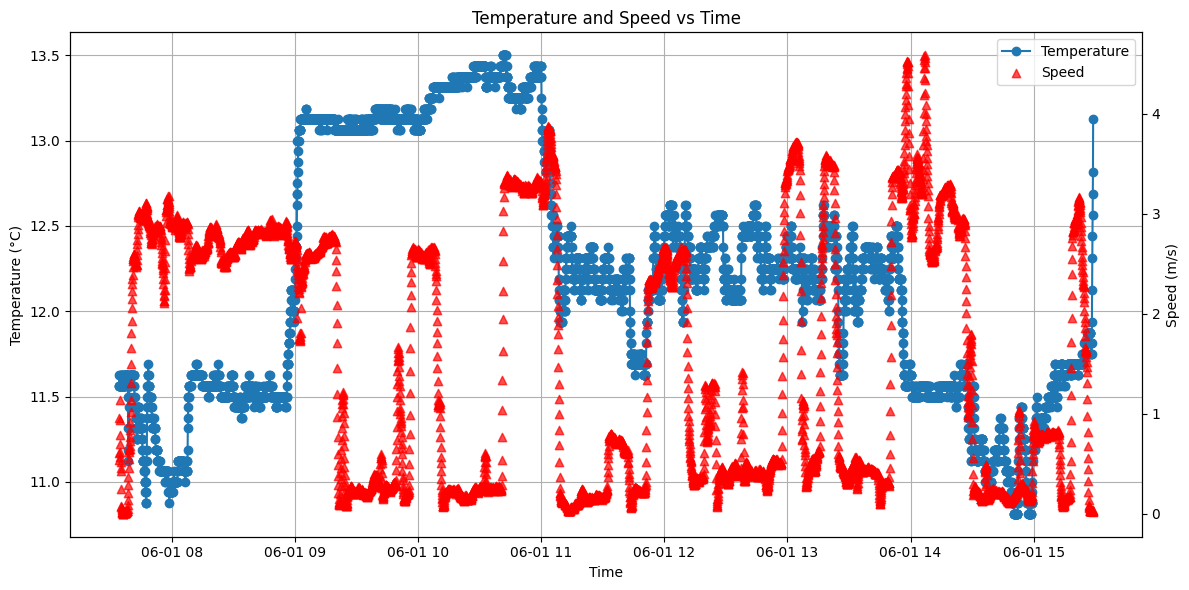

In [15]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Temperature on left y-axis
ax1.plot(
    df["Time (UTC)"],
    df[" Temp (deg C) DS18B20"],
    marker='o',
    linestyle='-',
    label='Temperature'
)
ax1.set_xlabel("Time")
ax1.set_ylabel("Temperature (°C)")
ax1.tick_params(axis='y')
ax1.grid(True)

# Create second y-axis
ax2 = ax1.twinx()

# Speed on right y-axis
ax2.scatter(
    df["Time (UTC)"],
    df["speed_mps_smooth"],
    label='Speed',
    marker='^',
    alpha=0.7,
    color = 'r'
)
ax2.set_ylabel("Speed (m/s)")
ax2.tick_params(axis='y')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.xticks(rotation=45)
plt.title("Temperature and Speed vs Time")
plt.tight_layout()
# Save combined figure
plt.savefig("Loch_Etive_260601_A007_Logger_Temp_Speed.png", dpi=300, bbox_inches="tight")

plt.show()

## Step 6: Plot lat and lon satellite map with speed overlain

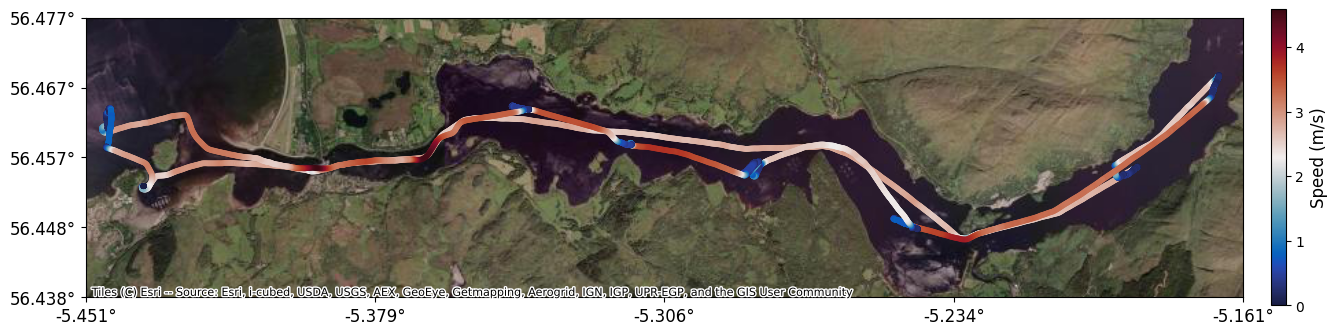

In [8]:
# Make coulmns unique
df.columns = make_column_names_unique(df.columns)

# Extract Lat and Lon
Lat = df[' Latitude (degs N)']
Lon = df[' Longitude (degs E)']

# Define area around transect 
Max_lon = np.max(Lon) + 0.006
Min_lon = np.min(Lon) - 0.004
Max_lat = np.max(Lat) + 0.008
Min_lat = np.min(Lat) - 0.008

# Extract indicies for plotting 
ASD = np.where(Lat >= Min_lat)[0]  # get the actual indices from the tuple
Lat1 = Lat.iloc[ASD]               # use .iloc for integer-based indexing
Lon1 = Lon.iloc[ASD]
ASD = np.where(Lat1 <= Max_lat)[0]
Lat1 = Lat1.iloc[ASD]               # use .iloc for integer-based indexing
Lon1 = Lon1.iloc[ASD]
ASD = np.where(Lon1 >= Min_lon)[0]
Lat1 = Lat1.iloc[ASD]               # use .iloc for integer-based indexing
Lon1 = Lon1.iloc[ASD]
ASD = np.where(Lon1 <= Max_lon)[0]
Lat1 = Lat1.iloc[ASD]               # use .iloc for integer-based indexing
Lon1 = Lon1.iloc[ASD]

# Create a transformer to convert from WGS84 (EPSG:4326) to Web Mercator (EPSG:3857)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

# Create transformers to convert back from Web Mercator (EPSG:3857) to WGS84 (EPSG:4326)
transformer_to_lonlat = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

# Convert coordinates from lat/lon to Web Mercator
x, y = transformer.transform(Lon1, Lat1)  # Ensure these are NumPy arrays or lists
xmin, ymin  = transformer.transform(Min_lon, Min_lat) 
xmax, ymax  = transformer.transform(Max_lon, Max_lat) 

# Define figure and axis
fig, (ax1) = plt.subplots(figsize=(15, 4))
ax1.set_ylim([ymin,ymax])
ax1.set_aspect(1)

# Scatter plot for station locations (now using converted coordinates)
im1 = ax1.scatter(
    x, y, 
    c=df['speed_mps_smooth'], 
    s=10, linewidths=1, 
    label="Speed", 
    marker='o', 
    cmap=cmocean.cm.balance
)

# Add OpenStreetMap basemap (now correctly projected)
ctx.add_basemap(ax1, source=ctx.providers.Esri.WorldImagery)

# Manually reset limits after adding basemap
ax1.set_xlim([xmin, xmax])
ax1.set_ylim([ymin, ymax])

# Adjust plot settings
ax1.tick_params(axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)

# Set custom tick locations (fewer ticks)
num_ticks = 5  # Adjust the number of ticks as needed
ax1.set_xticks(np.linspace(ax1.get_xlim()[0], ax1.get_xlim()[1], num_ticks))
ax1.set_yticks(np.linspace(ax1.get_ylim()[0], ax1.get_ylim()[1], num_ticks))

# Set major ticks format for Longitude (X-axis)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(merc_to_lonlat))

# Set major ticks format for Latitude (Y-axis)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(merc_to_latlon))

# Add colorbar
cbar = plt.colorbar(im1, ax=ax1, orientation="vertical", shrink=0.8, pad=0.02)
cbar.set_label("Speed (m/s)", fontsize=12)

# Make layout nice
plt.tight_layout()
plt.show()

## Option to save Figure
fig.savefig('Speed_map.png', format='png', dpi=300)

## Step 7: Plot lat and lon satellite map with temperatiure overlain

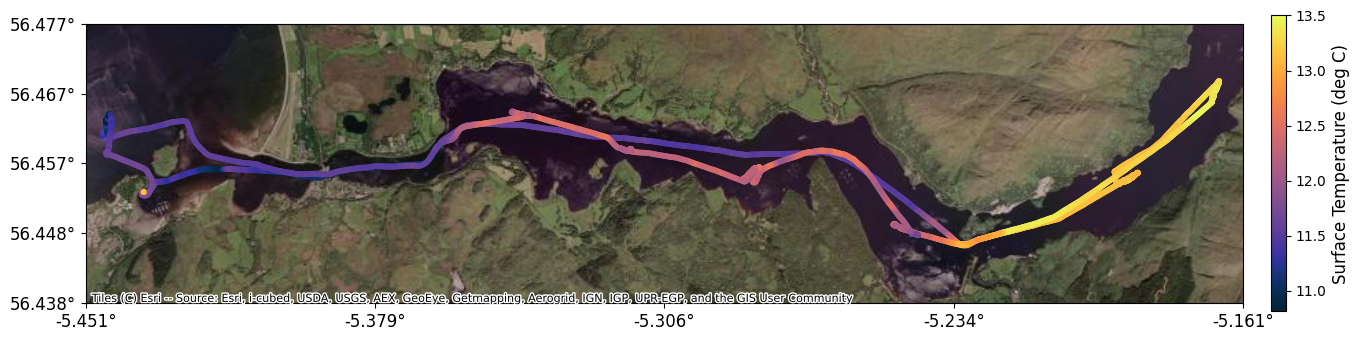

In [9]:
# Define figure and axis
fig, (ax2) = plt.subplots(figsize=(15, 4))
ax2.set_ylim([ymin,ymax])
ax2.set_aspect(1)

# Scatter plot for station locations (now using converted coordinates)
im2 = ax2.scatter(
    x, y, 
    c=df[" Temp (deg C) DS18B20"], 
    s=10, linewidths=1, 
    label="Temp", 
    marker='o', 
    cmap=cmocean.cm.thermal
)

# Add OpenStreetMap basemap (now correctly projected)
ctx.add_basemap(ax2, source=ctx.providers.Esri.WorldImagery)

# Manually reset limits after adding basemap
ax2.set_xlim([xmin, xmax])
ax2.set_ylim([ymin, ymax])

# Adjust plot settings
ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)

# Set custom tick locations (fewer ticks)
num_ticks = 5  # Adjust the number of ticks as needed
ax2.set_xticks(np.linspace(ax2.get_xlim()[0], ax2.get_xlim()[1], num_ticks))
ax2.set_yticks(np.linspace(ax2.get_ylim()[0], ax2.get_ylim()[1], num_ticks))

# Set major ticks format for Longitude (X-axis)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(merc_to_lonlat))
# Set major ticks format for Latitude (Y-axis)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(merc_to_latlon))

# Add colorbar
cbar = plt.colorbar(im2, ax=ax2, orientation="vertical", shrink=0.8, pad=0.02)
cbar.set_label("Surface Temperature (deg C)", fontsize=12)

# Make layout nice
plt.tight_layout()
plt.show()

# Option to save Figure
fig.savefig('Temperature_map.png', format='png', dpi=300)

## Step 8: Plot lat and lon satellite map with temperatiure overlain

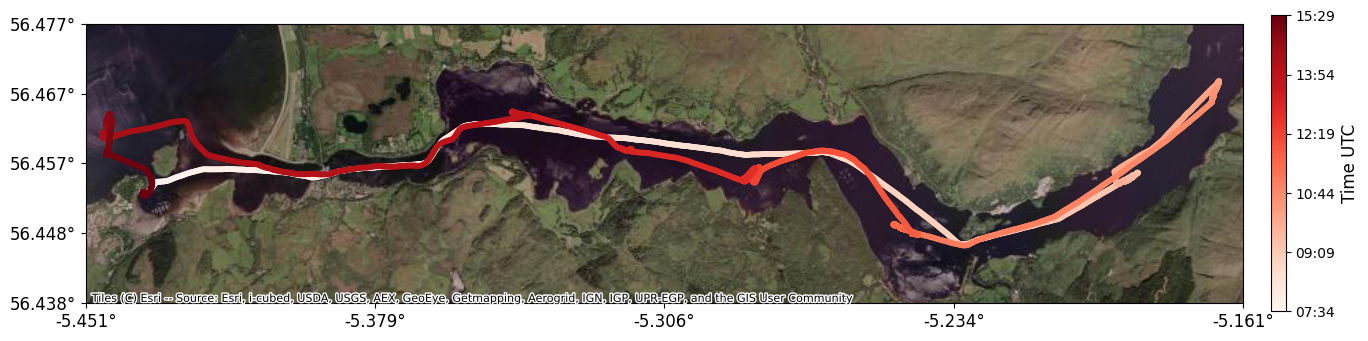

In [10]:
# Convert times to datetime (safe even if already datetime64)
times = pd.to_datetime(df["Time (UTC)"])

# Convert to seconds since midnight
seconds = (
    times.dt.hour * 3600 +
    times.dt.minute * 60 +
    times.dt.second
)

# Define figure and axis
fig, (ax2) = plt.subplots(figsize=(15, 4))
ax2.set_ylim([ymin, ymax])
ax2.set_aspect(1)

# Scatter plot for station locations
im2 = ax2.scatter(
    x, y,
    c=seconds,
    s=10,
    linewidths=1,
    label="Time",
    marker='o',
    cmap='Reds'
)

# Add basemap
ctx.add_basemap(ax2, source=ctx.providers.Esri.WorldImagery)

# Manually reset limits after adding basemap
ax2.set_xlim([xmin, xmax])
ax2.set_ylim([ymin, ymax])

# Adjust plot settings
ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)

# Set custom tick locations
num_ticks = 5
ax2.set_xticks(np.linspace(ax2.get_xlim()[0], ax2.get_xlim()[1], num_ticks))
ax2.set_yticks(np.linspace(ax2.get_ylim()[0], ax2.get_ylim()[1], num_ticks))

# Longitude / Latitude formatting
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(merc_to_lonlat))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(merc_to_latlon))

# Add colorbar
cbar = plt.colorbar(
    im2,
    ax=ax2,
    orientation="vertical",
    shrink=0.8,
    pad=0.02
)

# Format colorbar ticks as HH:MM
cbar.ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos:
        f"{int(x//3600):02d}:{int((x%3600)//60):02d}"
    )
)

# Optional: set a fixed number of time ticks
ticks = np.linspace(seconds.min(), seconds.max(), 6)
cbar.set_ticks(ticks)

cbar.set_label("Time UTC", fontsize=12)

# Make layout nice
plt.tight_layout()

# Save figure
fig.savefig('Time_map.png', format='png', dpi=300)

plt.show()

## Step 10: Combine figures

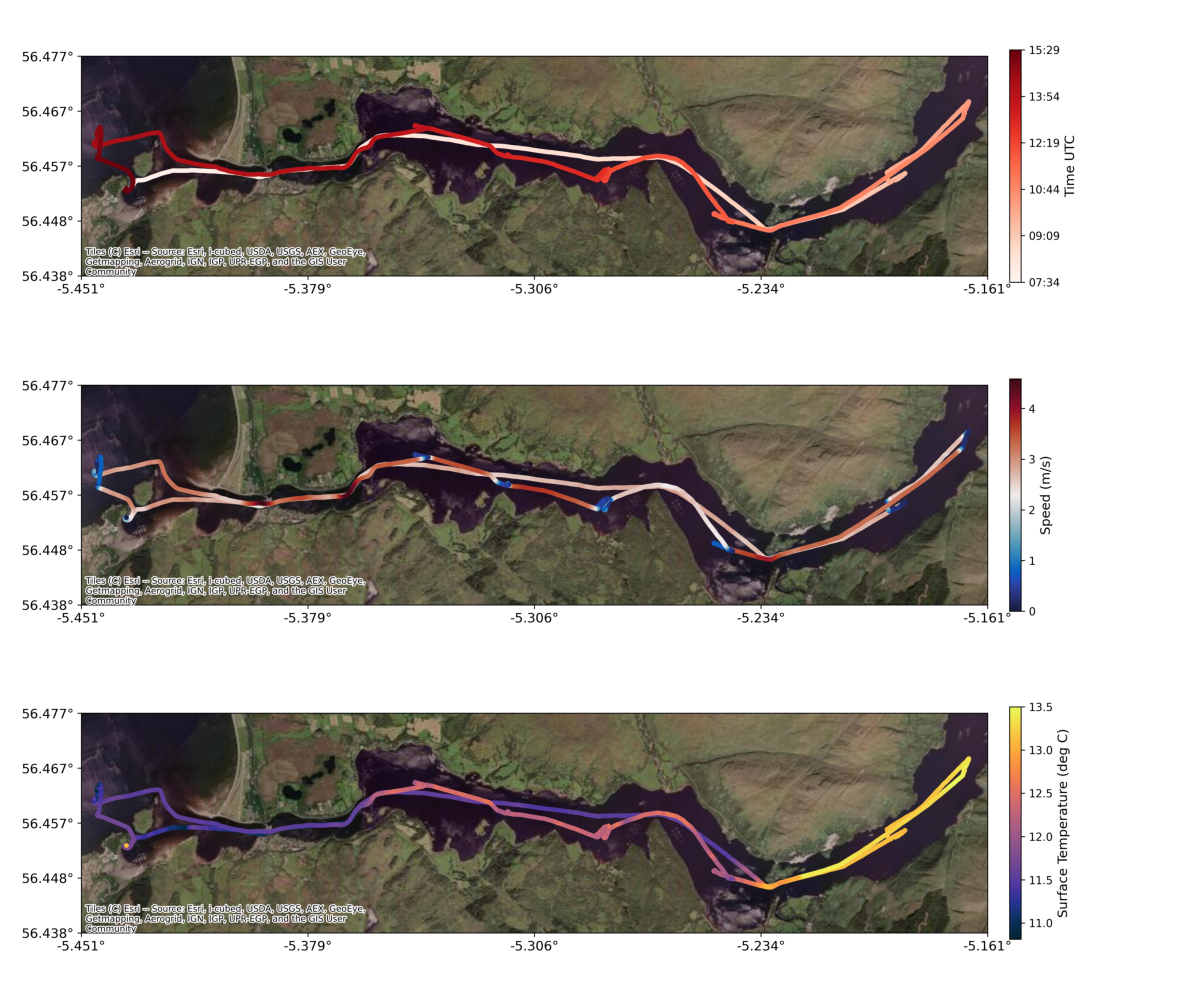

In [11]:
# Read images
time_img = mpimg.imread("Time_map.png")
speed_img = mpimg.imread("Speed_map.png")
temp_img = mpimg.imread("Temperature_map.png")

# Create stacked figure (3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Plot each image
axes[0].imshow(time_img)
axes[0].axis("off")
axes[1].imshow(speed_img)
axes[1].axis("off")
axes[2].imshow(temp_img)
axes[2].axis("off")
plt.tight_layout()

# Save combined figure
plt.savefig("Loch_Etive_260601_A007_Logger.png", dpi=300, bbox_inches="tight")

plt.show()